## 1. Library import

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Libraries for Bayesian modeling
import pymc as pm
import arviz as az

import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## 2. Directed acyclic graph

C:\Users\elsab\AppData\Local\Temp\ipykernel_25824\2868846603.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


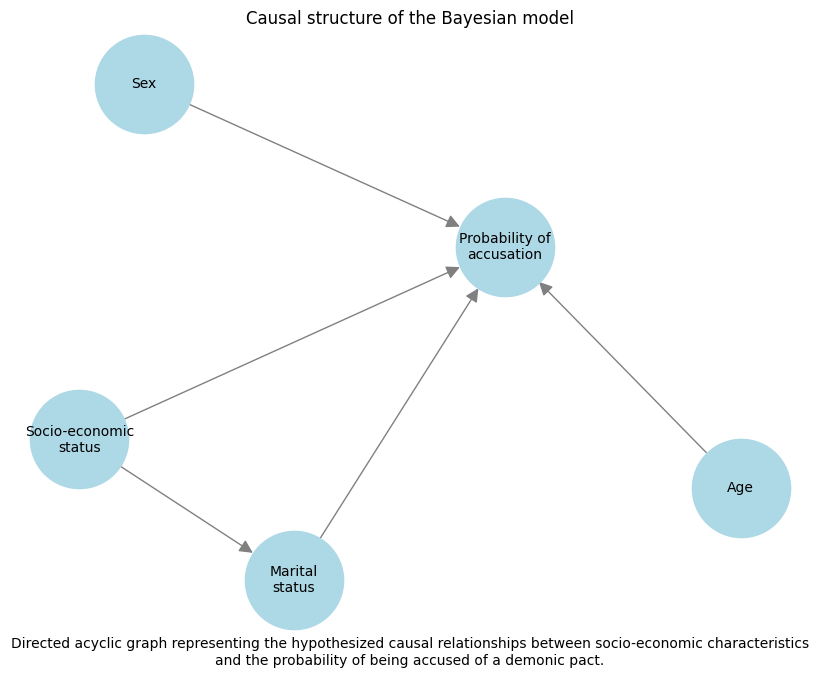

In [2]:
# Create directed graph
G = nx.DiGraph()

# Define nodes
nodes = [
    'Sex',
    'Age',
    'Marital\nstatus',
    'Socio-economic\nstatus',
    'Probability of\naccusation'
]

G.add_nodes_from(nodes)

# Define causal links
edges = [
    ('Sex', 'Probability of\naccusation'),
    ('Age', 'Probability of\naccusation'),
    ('Marital\nstatus', 'Probability of\naccusation'),
    ('Socio-economic\nstatus', 'Probability of\naccusation'),
    ('Socio-economic\nstatus', 'Marital\nstatus')
]

G.add_edges_from(edges)

# Layout
pos = nx.spring_layout(G, seed=42)

# Draw graph
plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=5000,
    node_color='lightblue',
    arrows=True,
    arrowsize=20,
    font_size=10,
    edge_color='gray'
)

# Caption
description = (
    "Directed acyclic graph representing the hypothesized "
    "causal relationships between socio-economic characteristics "
    "and the probability of being accused of a demonic pact."
)

plt.figtext(
    0.5,
    -0.05,
    description,
    wrap=True,
    horizontalalignment='center',
    fontsize=10
)

plt.title("Causal structure of the Bayesian model", fontsize=12)

plt.tight_layout()
plt.show()

## 3. Data import

In [3]:
df_witches = pd.read_csv('WDB_Accused.csv')
pd.set_option('display.max_columns', None)

In [4]:
df_case = pd.read_csv('WDB_Case.csv')

In [5]:
df = df_case.merge(df_witches, on="AccusedRef", how="inner")
df

,index_x,CaseRef,CaseId,CaseSystemId,NamedIndividual,AccusedRef,CaseStart_date,CaseStart_date_as_date,Case_date,Case_date_as_date,Age_at_case,CaseCommonName,Commission,Complaint,Correspondence,Chronicle,Other,Suspects_text,UNorthodoxRelPract_p,UNorthodoxRelPract_s,Consulting_p,Consulting_s,Demonic_p,Demonic_s,Demonic_possess_p,Demonic_possess_s,Fairies_p,Fairies_s,Folk_healing_p,Folk_healing_s,Maleficium_p,Maleficium_s,Midwifery_p,Midwifery_s,ImplicatedByAnother_p,ImplicatedByAnother_s,Neighbhd_dispute_p,Neighbhd_dispute_s,PoliticalMotive_p,PoliticalMotive_s,PropertyMotive_p,PropertyMotive_s,RefusedCharity_p,RefusedCharity_s,Treason_p,Treason_s,Other_p,Other_s,OtherText,NotEnoughInfo_p,NotEnoughInfo_s,WhiteMagic_p,WhiteMagic_s,Charnotes,DemonicPact,DevilNotes,WitchesMeeting,MeetingName,DevilPresent,Maleficium,CommunalSex,DevilWorship,FoodAndDrink,Dancing,Singing,SingingText,OtherPractices,MeetingNotes,Elphane/Fairyland,Food/Drink,SpecificVerbalFormulae,SpecificRitualActs,Familiars,Shape-Changing,Dreams/Visions,UnorthodoxReligiousPractice,SympatheticMagic,Ridingdead,FolkNotes,HumanIllness,HumanDeath,AnimalIllness,AnimalDeath,FemaleInfertility,MaleImpotence,AggravatingDisease,TransferringDisease,LayingOn,Removalbewitchment,Quarreling,Cursing,Poisoning,RecHealer,HealingHumans,HealingAnimals,Midwifery,DiseaseNotes,PropertyDamage,WeatherModification,OtherMaleficiaNotes,OtherChargesNotes,ClaimedBewitched,ClaimedPossessed,AdmitLesserCharge,ClaimedNaturalCauses,Nodefence,DefenseNotes,CaseNotes,Createdby_x,Createdate_x,Lastupdatedby_x,Lastupdatedon_x,index_y,AccusedSystemId,AccusedID,FirstName,LastName,M_Firstname,M_Surname,Alias,Patronymic,DesTitle,Sex,Age,Age_estcareer,Age_estchild,Res_settlement,Res_parish,Res_presbytery,Res_county,Res_burgh,Res_NGR_Letters,Res_NGR_Easting,Res_NGR_Northing,Ethnic_origin,MaritalStatus,SocioecStatus,Occupation,Notes,Createdby_y,Createdate_y,Lastupdatedby_y,Lastupdatedon_y
0,1,C/EGD/100,100,EGD,-1.0,A/EGD/89,27/1/1591,01/27/91 00:00:00,8/5/1591,05/08/91 00:00:00,NaN,"Kerington,Cristine",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1,0,0,Part of the North Berwick witch hunt. It invo...,0,Said by others to have met the devil as a 'mek...,0,NaN,0,0,0,0,0,0,0,NaN,NaN,See Agnes Sampson's case for description of No...,0,0,0,0,0,0,0,0,0,0,In other accused's confession it was said that...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,NaN,NaN,0,0,0,0,0,NaN,NaN,SMD,05/15/01 17:00:16,jhm,10/10/02 14:51:54,2264,EGD,89,Cristine,Kerington,Christine,Carrington,Lukit,NaN,NaN,Female,NaN,0,0,NaN,NaN,NaN,Haddington,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SMD,05/15/01 11:06:51,jhm,09/18/02 15:21:25
1,2,C/EGD/1000,1000,EGD,-1.0,A/EGD/989,6/5/1627,05/06/27 00:00:00,6/5/1627,05/06/27 00:00:00,NaN,"Craig,Christiane",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1,0,0,NaN,0,NaN,0,NaN,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,NaN,NaN,0,0,0,0,0,NaN,NaN,SMD,05/15/01 17:00:16,jhm,10/09/02 15:52:09,2369,EGD,989,Christiane,Craig,Christine,Craig,NaN,NaN,NaN,Female,NaN,0,0,NaN,P/ST/1538,Turriff,Aberdeen,NaN,NaN,NaN,NaN,NaN,Married,NaN,NaN,Husband also accused of Witchcraft.,SMD,05/15/01 11:06:51,jhm,10/01/02 10:01:18
2,3,C/EGD/1001,1001,EGD,-1.0,A/EGD/990,NaN,NaN,25/4/1627,04/25/27 00:00:00,NaN,"Ronaldson,Margaret",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1,0,0,NaN,0,NaN,0,NaN,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,NaN,NaN,0,0,0,0,0,NaN,NaN,SMD,05/15/01 17:00:16,jhm,09/18/02 15:23:08,2371,EGD,990,Margaret,Ronaldson,Margaret,Ronaldson,NaN,NaN,NaN,Female,NaN,0,0,NaN,P/ST/421,Aberdeen,Aberdeen,Aberdeen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SMD,05/15/01 11:06:51,jhm,09/18/02 15:23:08
3,4,C/EGD/1002,1002,EGD,-1.0,A/EGD/991,NaN,NaN,3/5/1627,05/03/27 00:00:00,NaN,"Broun,Bessie",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0

## 4. Data manipulation

In [6]:
# Transform categorical variables into dummy variables
df_encoded = pd.get_dummies(df, columns=[
    "Sex",
    "MaritalStatus",
    "SocioecStatus"
], drop_first=True)

# Transform True/False values into 1/0
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [7]:
# Selecting the variables used in the model
variables = [col for col in df_encoded.columns 
             if col.startswith("Sex_") 
             or col.startswith("MaritalStatus_") 
             or col == "Age"]

df_encoded = df_encoded.dropna(subset=variables + ["Demonic_s"]) # Drop NaN values in the selected variables

X = df_encoded[variables]
y = df_encoded["Demonic_s"].values
X

,Age,Sex_Male,MaritalStatus_Irregular union,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
17,50.0,0,0,0,0,0
26,42.0,0,0,0,0,0
30,43.0,0,0,1,0,0
35,25.0,0,0,0,0,0
36,50.0,0,0,1,0,0
...,...,...,...,...,...,...
2751,50.0,0,0,0,0,0
2857,50.0,0,0,0,0,0
2868,14.0,1,0,0,0,0
2877,30.0,0,0,0,0,0


## 5. Data description

In [8]:
df['Age'] = df['Age'].apply(lambda x: x if np.isnan(x) else int(x))

Text(0, 0.5, 'Number of Trials')

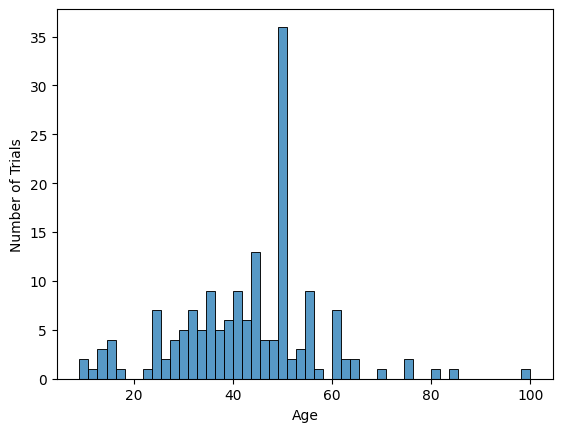

In [9]:
# Histogram of age distribution
sns.histplot(df_encoded['Age'], bins=50)
plt.gca().set_xlabel("Age")
plt.gca().set_ylabel("Number of Trials")

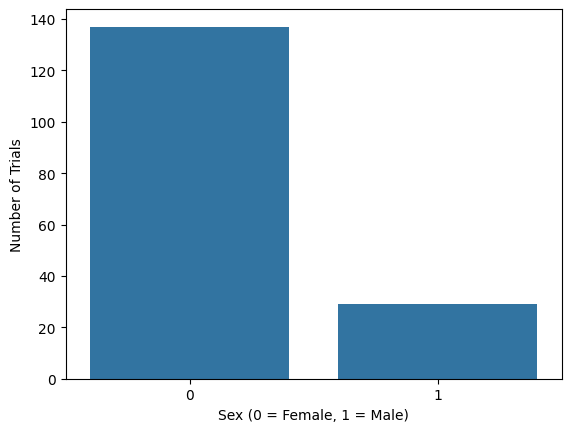

In [10]:
# Count plot for sex
counts = df_encoded['Sex_Male'].value_counts()
sns.barplot(x = counts.index, y = counts.values)
plt.gca().set_xlabel("Sex (0 = Female, 1 = Male)")
plt.gca().set_ylabel("Number of Trials")
plt.show()

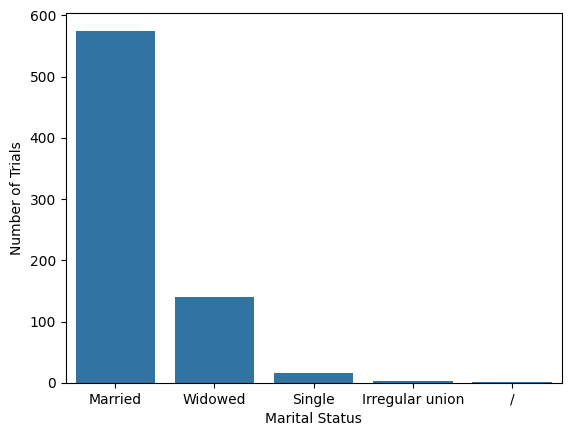

In [11]:
# Count plot for marial status
counts = df['MaritalStatus'].value_counts()
sns.barplot(x = counts.index, y = counts.values)
plt.gca().set_xlabel("Marital Status")
plt.gca().set_ylabel("Number of Trials")
plt.show()

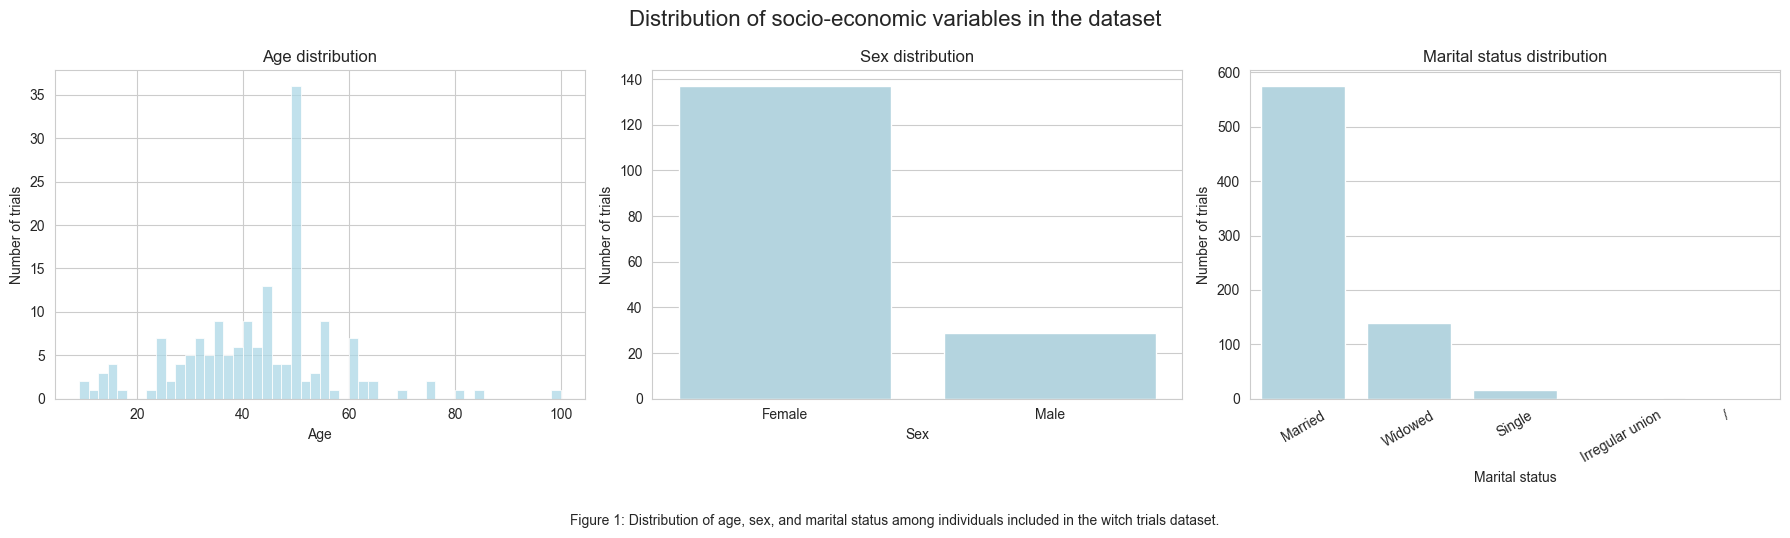

In [12]:
# Style
sns.set_style("whitegrid")

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
sns.histplot(
    df_encoded['Age'],
    bins=50,
    color='lightblue',
    edgecolor='white',
    ax=axes[0]
)

axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of trials")

# Sex distribution
counts_sex = df_encoded['Sex_Male'].value_counts().sort_index()

sns.barplot(
    x=["Female", "Male"],
    y=counts_sex.values,
    color='lightblue',
    ax=axes[1]
)

axes[1].set_title("Sex distribution")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Number of trials")

# Marital status distribution
counts_marital = df['MaritalStatus'].value_counts()

sns.barplot(
    x=counts_marital.index,
    y=counts_marital.values,
    color='lightblue',
    ax=axes[2]
)

axes[2].set_title("Marital status distribution")
axes[2].set_xlabel("Marital status")
axes[2].set_ylabel("Number of trials")

# Rotate labels for readability
axes[2].tick_params(axis='x', rotation=30)

# Global title
fig.suptitle(
    "Distribution of socio-economic variables in the dataset",
    fontsize=16
)

# Description
description = (
    "Figure 1: Distribution of age, sex, and marital status "
    "among individuals included in the witch trials dataset."
)

plt.figtext(
    0.5,
    -0.05,
    description,
    wrap=True,
    horizontalalignment='center',
    fontsize=10
)

plt.tight_layout()
plt.show()

## 6. Linear model

In [13]:
# Data standardization
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [14]:
n_features = X.shape[1]

with pm.Model() as model:
    
    # Priors
    beta = pm.Normal("beta", mu=0, sigma=1, shape=n_features)
    intercept = pm.Normal("intercept", mu=0, sigma=1)
    
    # Logit
    logit_p = intercept + pm.math.dot(X, beta)
    
    # Likelihood
    y_obs = pm.Bernoulli("y_obs", logit_p=logit_p, observed=y)
    
    # Sampling
    trace = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        cores=1,
        target_accept=0.9
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [beta, intercept]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 192 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


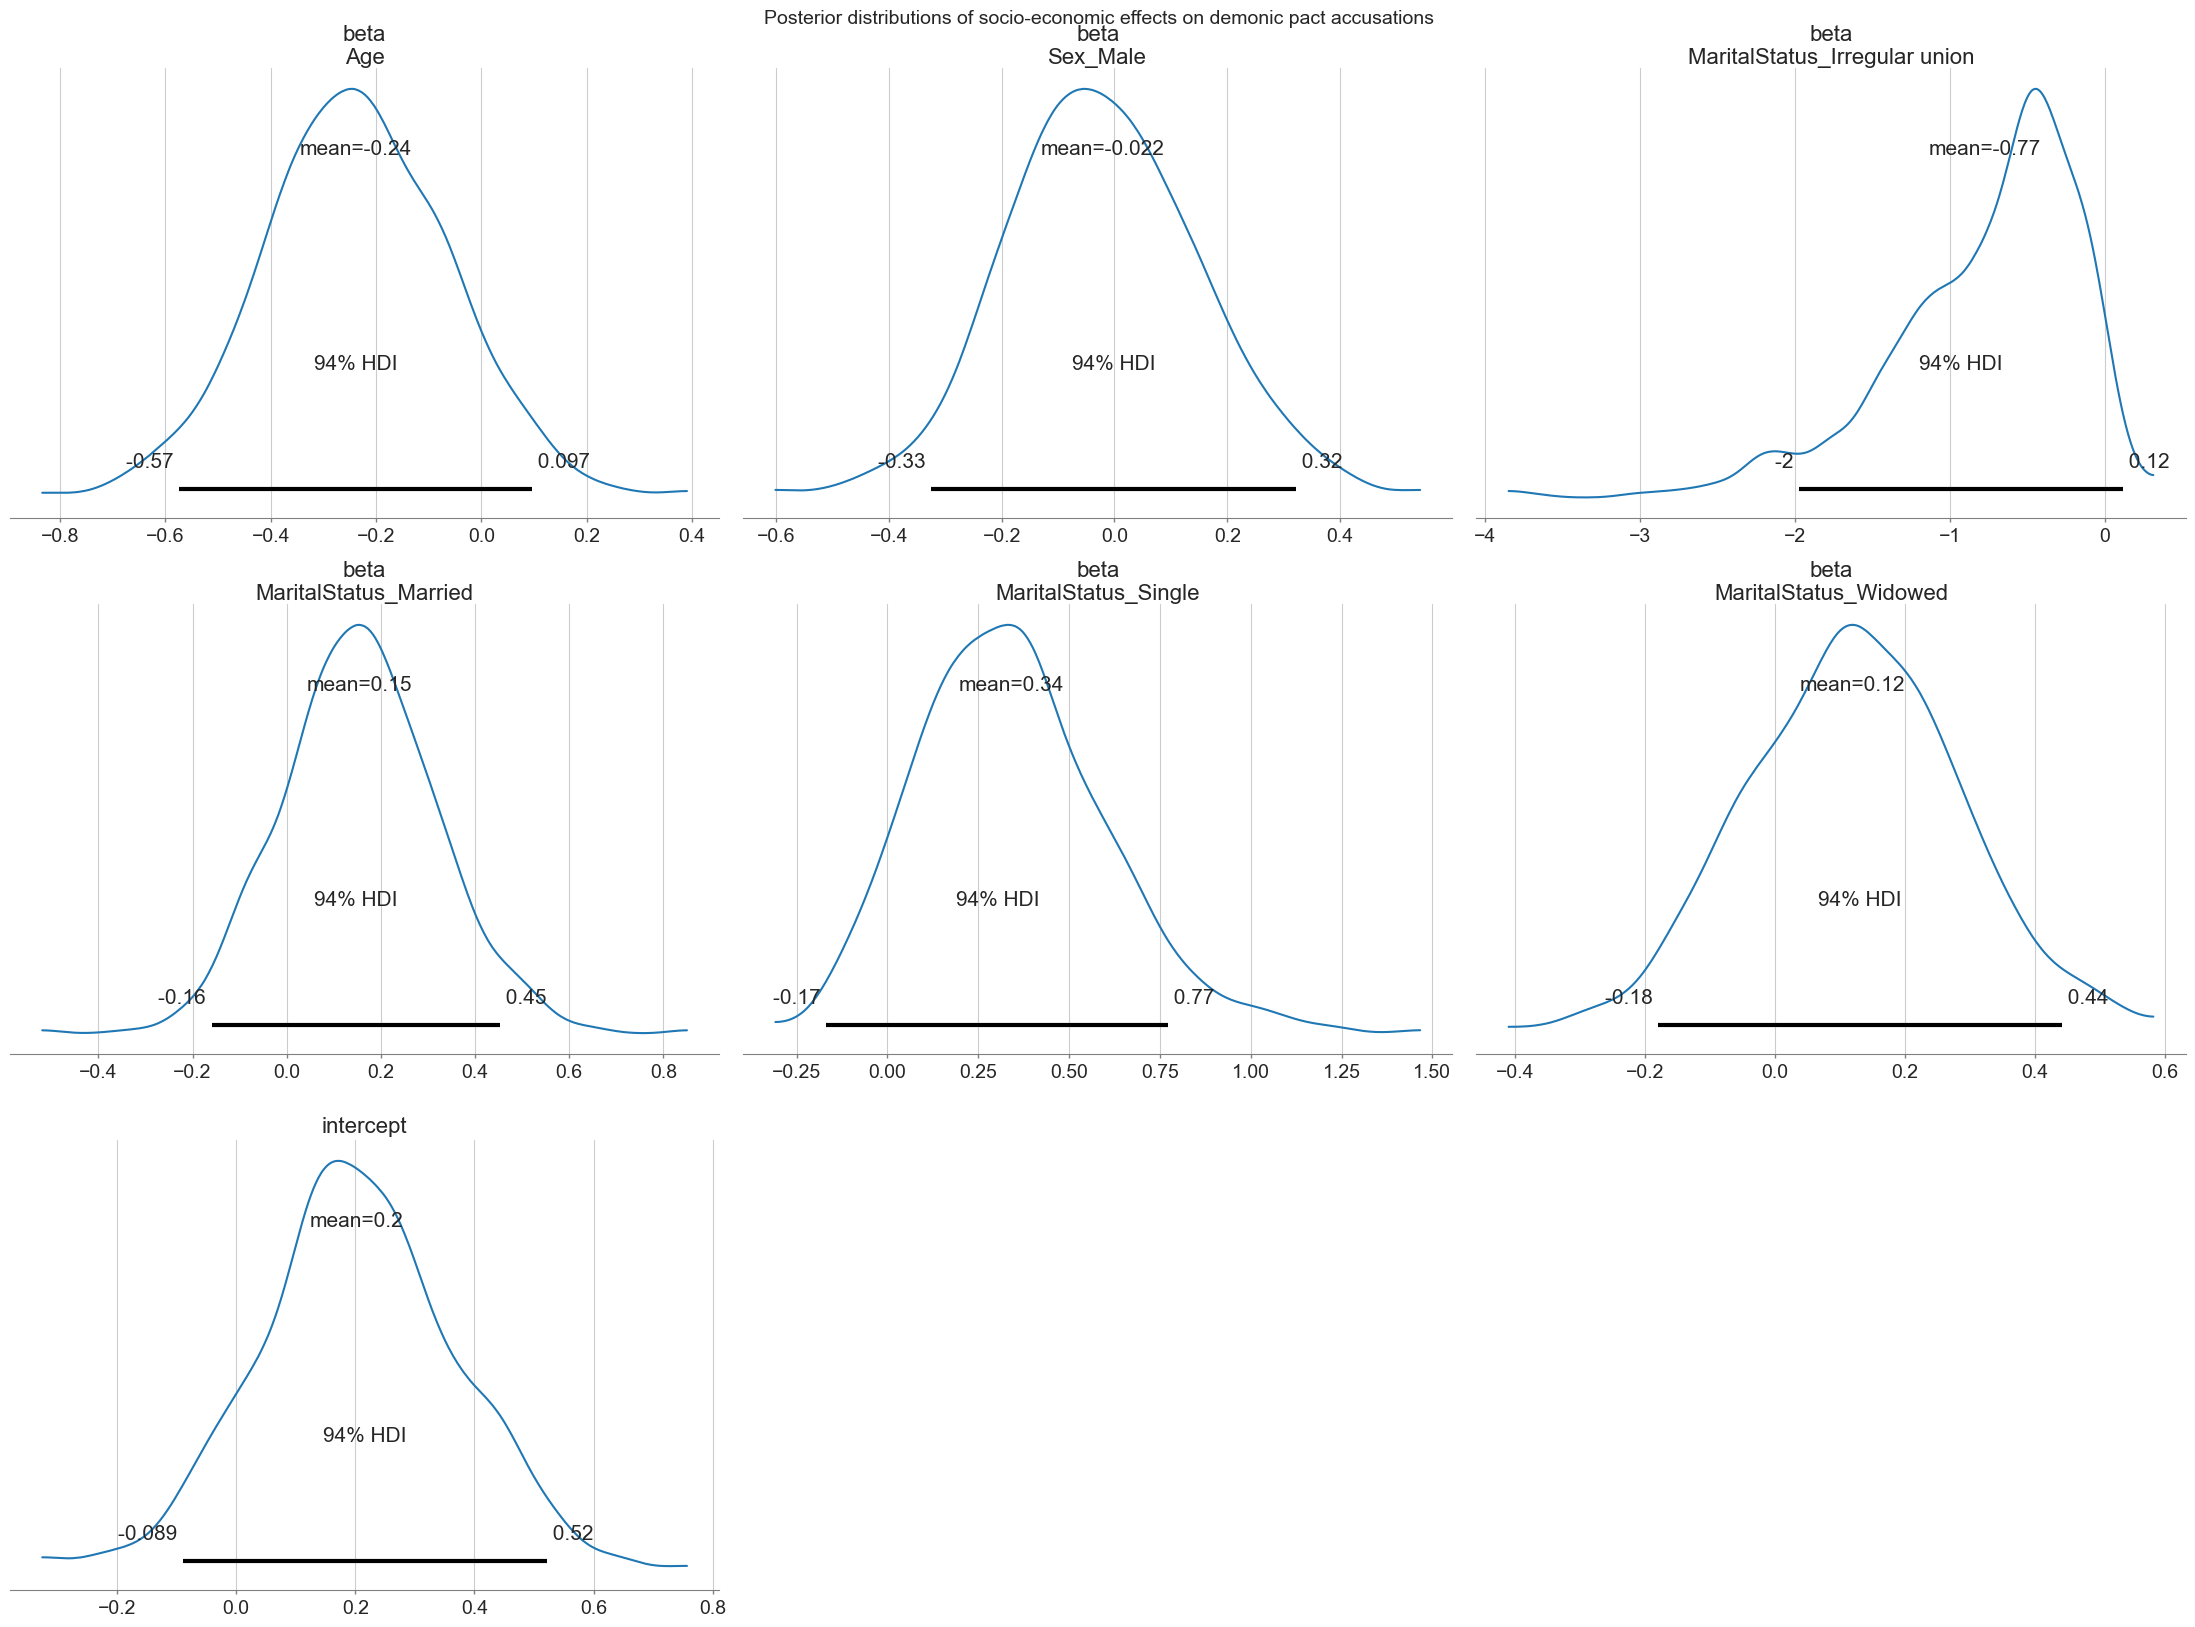

In [15]:
feature_names = df_encoded[variables].columns.tolist()

idata = trace

# Trouver le vrai nom de la dimension de beta
beta_dims = idata.posterior["beta"].dims
dim_name = idata.posterior["beta"].dims[-1]

idata.posterior = idata.posterior.assign_coords(
    {dim_name: feature_names}
)

az.plot_posterior(idata, var_names=["beta", "intercept"])
plt.suptitle(
    "Posterior distributions of socio-economic effects on demonic pact accusations",
    fontsize=14
)
plt.tight_layout()

In [16]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[Age],-0.238,0.178,-0.574,0.097,0.005,0.007,1092.0,743.0,1.0
beta[Sex_Male],-0.022,0.173,-0.325,0.322,0.005,0.006,1006.0,744.0,1.0
beta[MaritalStatus_Irregular union],-0.772,0.613,-1.976,0.120,0.029,0.028,582.0,358.0,1.0
beta[MaritalStatus_Married],0.155,0.164,-0.159,0.452,0.006,0.005,836.0,679.0,1.0
beta[MaritalStatus_Single],0.341,0.259,-0.168,0.773,0.010,0.008,802.0,630.0,1.0
beta[MaritalStatus_Widowed],0.119,0.164,-0.180,0.442,0.006,0.005,880.0,726.0,1.0
intercept,0.203,0.165,-0.089,0.521,0.006,0.004,734.0,748.0,1.0


In [17]:
summary = az.summary(idata)

beta_age = summary.loc["beta[Age]", "mean"]
beta_single = summary.loc["beta[MaritalStatus_Single]", "mean"]
beta_irregular = summary.loc["beta[MaritalStatus_Irregular union]", "mean"]
beta_male = summary.loc["beta[Sex_Male]", "mean"]

# Hypotheses evaluation

# H1a: being female increases accusations
# Since the variable is Sex_Male:
# negative beta -> men less accused -> women more accused
H1a_supported = beta_male < 0

# H1b: being single increases accusations
H1b_supported = beta_single > 0

# H1c: irregular union increases accusations
H1c_supported = beta_irregular > 0

# H1d: age influences accusations
# non-directional hypothesis -> check if effect meaningfully differs from 0
H1d_supported = abs(beta_age) > 0.05

print("H1a (being female increases accusations):", H1a_supported)
print("H1b (being single increases accusations):", H1b_supported)
print("H1c (irregular union increases accusations):", H1c_supported)
print("H1d (age influences accusations):", H1d_supported)

H1a (being female increases accusations): True
H1b (being single increases accusations): True
H1c (irregular union increases accusations): False
H1d (age influences accusations): True
